# 3. Kernels: astrometry measures odd degrees, photometry even

The forward model's sensitivity to each harmonic $(l, m)$ is encoded by
kernel terms $k^h_{l,m} = \mathcal{A}_h(Y_l^m)$ — the photocenter (first
moment) or flux (zeroth moment) of a single static harmonic over the
visible hemisphere. Section 2.2 of the paper derives them analytically and
proves the selection rules:

* **astrometry**: non-zero only for odd $l$ (and $l \le 2$) — modes
  *anti-symmetric* about the equator; x-kernel needs odd $m$, y-kernel
  even $m$;
* **photometry**: non-zero only for even $l$ (and $l \le 2$) — modes
  *symmetric* about the equator (Cowan et al. 2013; Luger et al. 2021).

Astrometry and photometry therefore probe **orthogonal subspaces** of the
surface, and jointly they sample every degree.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm


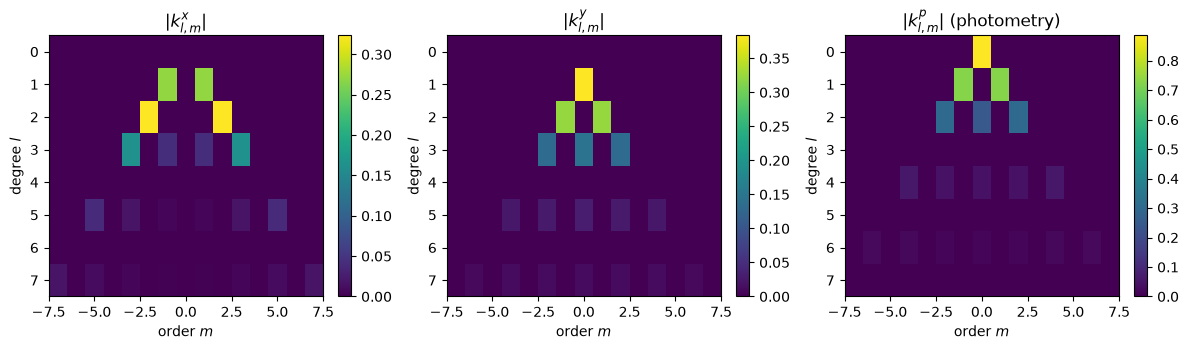

In [2]:
from jittermap.forward.kernels import compute_A_lm, compute_A_lm_photo

L = 7
A_x, A_y = compute_A_lm(L)
A_p = compute_A_lm_photo(L)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, A, title in zip(axes, [A_x, A_y, A_p],
                        ["$|k^x_{l,m}|$", "$|k^y_{l,m}|$",
                         "$|k^p_{l,m}|$ (photometry)"]):
    im = ax.imshow(np.abs(A), cmap="viridis", aspect="auto",
                   extent=[-L-0.5, L+0.5, L+0.5, -0.5])
    ax.set_title(title); ax.set_xlabel("order $m$"); ax.set_ylabel("degree $l$")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

The pyramid plots make the selection rules visible: the astrometric kernels
occupy odd rows (plus $l \le 2$) with alternating-parity columns, the
photometric kernel the even rows. Rows with $l>2$ of the *wrong* parity are
identically zero.

In [3]:
print("astrometric kernel power per degree (x-axis):")
for l in range(L+1):
    print(f"  l={l}:  {np.sum(np.abs(A_x[l])**2):.2e}   "
          f"photometric: {np.sum(np.abs(A_p[l])**2):.2e}")

astrometric kernel power per degree (x-axis):
  l=0:  0.00e+00   photometric: 7.85e-01
  l=1:  1.47e-01   photometric: 1.05e+00
  l=2:  2.09e-01   photometric: 2.45e-01
  l=3:  5.73e-02   photometric: 0.00e+00
  l=4:  0.00e+00   photometric: 1.23e-02
  l=5:  3.52e-03   photometric: 0.00e+00
  l=6:  0.00e+00   photometric: 2.49e-03
  l=7:  8.05e-04   photometric: 0.00e+00


## The photometric null space, demonstrated

Add a pure odd-degree ($l=3$) perturbation to a surface: the light curve is
**unchanged at machine precision** for any rotation and inclination, while
the astrometric signal clearly responds. This is exactly the degeneracy of
light-curve inversion that astrometry breaks.

In [4]:
L, N = 10, 150
times = np.linspace(0, 2*np.pi, N, endpoint=False)
fm = jm.ForwardModel(times, l_max=L)
sh = jm.SHIndexer(L)

s_base = jm.multispot_surface([(25, 300, 14.0)], L)

# pure l=3 real perturbation
pert = np.zeros(sh.total_coeffs, dtype=complex)
pert[sh.get_index(3, 0)] = 0.05
pert[sh.get_index(3, 2)] = 0.03 + 0.02j
pert[sh.get_index(3, -2)] = np.conj(pert[sh.get_index(3, 2)])
s_pert = s_base + pert

beta = 0.7
y0 = fm.observe(s_base, beta, channels="xyp", stacked=False)
y1 = fm.observe(s_pert, beta, channels="xyp", stacked=False)
print("max change in photometry :", np.abs(y1['p'] - y0['p']).max())
print("max change in astrometry :", max(np.abs(y1['x'] - y0['x']).max(),
                                        np.abs(y1['y'] - y0['y']).max()))

max change in photometry : 0.0
max change in astrometry : 0.00950469109995564


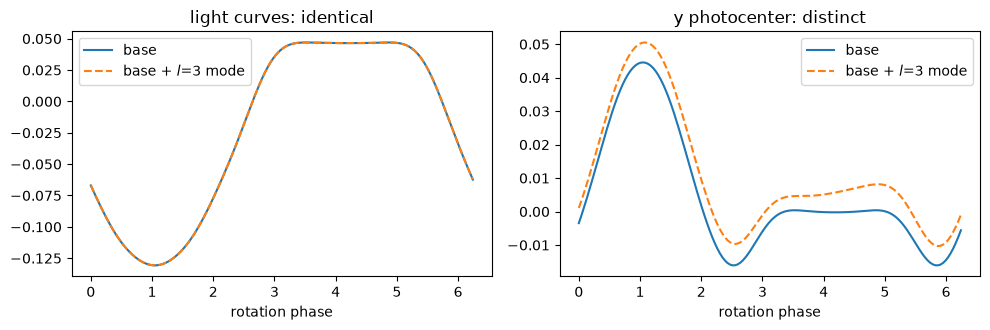

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(times, y0["p"], label="base")
axes[0].plot(times, y1["p"], "--", label="base + $l$=3 mode")
axes[0].set_title("light curves: identical"); axes[0].legend()
axes[1].plot(times, y0["y"], label="base")
axes[1].plot(times, y1["y"], "--", label="base + $l$=3 mode")
axes[1].set_title("y photocenter: distinct"); axes[1].legend()
for ax in axes: ax.set_xlabel("rotation phase")
plt.tight_layout()